In [200]:
import pandas as pd
import numpy as np 
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [201]:
data = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv")
data.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [202]:
df = data.copy()

In [203]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [204]:
df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [205]:
categorical = list(df.dtypes[df.dtypes == "object"].index)
numerical = list(df.dtypes[df.dtypes != "object"].index)
numerical_no_target = ['number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score']

In [206]:
df[categorical].isnull().sum()

lead_source          128
industry             134
employment_status    100
location              63
dtype: int64

In [207]:
df[numerical].isnull().sum()

number_of_courses_viewed      0
annual_income               181
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [208]:
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0)

In [209]:
df[categorical].isnull().sum()

lead_source          0
industry             0
employment_status    0
location             0
dtype: int64

In [210]:
df[numerical].isnull().sum()

number_of_courses_viewed    0
annual_income               0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [211]:
from sklearn.model_selection import train_test_split
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

## Question 1: ROC AUC feature importance

In [212]:
scores = {}

for feat in numerical_no_target:
    score = roc_auc_score(y_train, df_train[feat])
    
    if score < 0.5:
        score = roc_auc_score(y_train, -df_train[feat])    

    scores[feat] = score

scores

{'number_of_courses_viewed': 0.7635680590007088,
 'annual_income': 0.5519578313253012,
 'interaction_count': 0.738270176293409,
 'lead_score': 0.6144993577250176}

In [213]:
max(scores, key=scores.get)

'number_of_courses_viewed'

## Question 2: Training the model

In [214]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [215]:
def train(df_train, y_train, C):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer()
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='lbfgs', C=C, max_iter=10000)
    # model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    
    model.fit(X_train, y_train)
    
    return dv, model

In [216]:
def predict(df, dv, model):
    dicts = df.to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [217]:
dv, model = train(df_train, y_train, C=1)
y_pred = predict(df_val, dv, model)
round(roc_auc_score(y_val, y_pred).item(), 3)

0.92

## Question 3: Precision and Recall

In [218]:
scores = []

thresholds = np.linspace(0, 1, 101)

for threshold in thresholds:
    precision = precision_score(y_val, y_pred >= threshold, zero_division=np.nan)
    recall = recall_score(y_val, y_pred >= threshold, zero_division=np.nan)
    scores.append((threshold, precision, recall))


columns = ["threshold", "precision", "recall"]
df_scores = pd.DataFrame(scores, columns=columns)

In [244]:
df_scores

,threshold,precision,recall,f1
0,0.00,0.583618,1.000000,0.737069
1,0.01,0.595819,1.000000,0.746725
2,0.02,0.610714,1.000000,0.758315
3,0.03,0.611511,0.994152,0.757238
4,0.04,0.618182,0.994152,0.762332
...,...,...,...,...
96,0.96,0.969697,0.374269,0.540084
97,0.97,1.000000,0.339181,0.506550
98,0.98,1.000000,0.274854,0.431193
99,0.99,1.000000,0.228070,0.371429


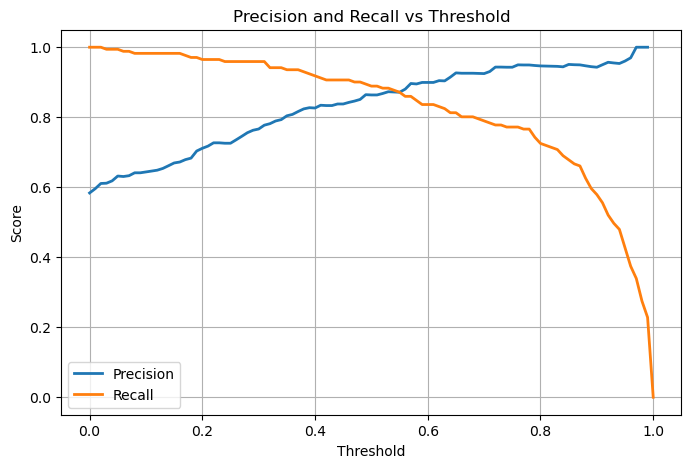

In [245]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(df_scores['threshold'], df_scores['precision'], label='Precision', linewidth=2)
plt.plot(df_scores['threshold'], df_scores['recall'], label='Recall', linewidth=2)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()


In [246]:
df_valid = df_scores.dropna(subset=['precision']).copy()

df_valid['diff'] = abs(df_valid['precision'] - df_valid['recall'])


idx = df_valid['diff'].idxmin()

intersection_threshold = df_valid.loc[idx, 'threshold']
precision_at_intersection = df_valid.loc[idx, 'precision']
recall_at_intersection = df_valid.loc[idx, 'recall']

print(f"Intersection at threshold = {intersection_threshold:.3f}")
print(f"Precision = {precision_at_intersection:.3f}, Recall = {recall_at_intersection:.3f}")

Intersection at threshold = 0.550
Precision = 0.871, Recall = 0.871


## Question 4

In [222]:
f1_scores = []

for threshold in thresholds:
    f1 = f1_score(y_val, y_pred >= threshold, zero_division=np.nan)
    f1_scores.append(f1)

df_scores["f1"] = f1_scores

In [223]:
df_scores.loc[df_scores['f1'].idxmax()]

threshold    0.490000
precision    0.864407
recall       0.894737
f1           0.879310
Name: 49, dtype: float64

## Question 5: 5-Fold CV

In [224]:
from sklearn.model_selection import KFold

In [239]:
def train_linear_solver(df_train, y_train, C):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer()
    X_train = dv.fit_transform(dicts)

    # model = LogisticRegression(solver='lbfgs', C=C, max_iter=10000)
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    
    model.fit(X_train, y_train)
    
    return dv, model

In [247]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    del df_train['converted']
    del df_val['converted']

    dv, model = train_linear_solver(df_train, y_train, C=1)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

round(np.std(scores), 4)

0.0358

## Question 6: Hyperparameter Tuning

In [236]:
from tqdm.auto import tqdm

In [248]:
n_splits = 5

for C in tqdm([0.000001, 0.001, 1]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values
        
        del df_train['converted']
        del df_val['converted']

        dv, model = train_linear_solver(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|          | 0/3 [00:00<?, ?it/s]

C=1e-06 0.560 +- 0.024
C=0.001 0.867 +- 0.029
C=1 0.822 +- 0.036
